In [1]:
import os
import math
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    classification_report, precision_recall_curve, confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

from imblearn.combine import SMOTETomek

import warnings
warnings.filterwarnings('ignore')

os.makedirs("../models", exist_ok=True)
print("🚀 Environment Ready. All advanced libraries loaded.")

🚀 Environment Ready. All advanced libraries loaded.


In [2]:
DATA_PATH = "../data/processed/final_gene_features.csv"
df = pd.read_csv(DATA_PATH)

drop_cols = ["GeneSymbol", "description", "label", "pathogenic_variants"]
features = [c for c in df.columns if c not in drop_cols]

X = df[features]
y = df["label"]

print(f"Features loaded: {len(features)}")
print(f"Raw Class Distribution: {Counter(y)}")

Features loaded: 45
Raw Class Distribution: Counter({0: 14914, 1: 8136})


Split, Scale, and Clean (SMOTE-Tomek)

In [3]:
# 1. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. DataFrame-Safe Scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

joblib.dump(scaler, "../models/feature_scaler.pkl")

# 3. Apply SMOTE-Tomek to the Training Data ONLY
print("Cleaning data boundary with SMOTE-Tomek (This may take a minute)...")
smt = SMOTETomek(random_state=42, n_jobs=-1)
X_train_clean, y_train_clean = smt.fit_resample(X_train_scaled, y_train)

# Convert back to DataFrame to preserve feature names
X_train_clean = pd.DataFrame(X_train_clean, columns=X_train.columns)

print(f"Cleaned (SMOTE-Tomek) Target: {Counter(y_train_clean)}")
print("✅ Dataset perfectly balanced and noisy borders removed!")

Cleaning data boundary with SMOTE-Tomek (This may take a minute)...
Cleaned (SMOTE-Tomek) Target: Counter({1: 11728, 0: 11728})
✅ Dataset perfectly balanced and noisy borders removed!


Hyperparameter Tuning (Random Forest, SVM, LR, Gradient Boost)
- This cell uses RandomizedSearchCV to test dozens of parameter combinations and automatically find the best ones for your specific biological data.

In [4]:
print("🚀 Initiating Hyperparameter Tuning for Base Models...\n")

tuned_models = {}

# 1. Random Forest Tuning
print("Tuning Random Forest...")
rf_param_grid = {
    'n_estimators': [200, 500, 800],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), 
                               rf_param_grid, n_iter=10, cv=3, scoring='f1', n_jobs=-1, random_state=42)
rf_search.fit(X_train_clean, y_train_clean)
tuned_models['RandomForest'] = rf_search.best_estimator_
joblib.dump(tuned_models['RandomForest'], "../models/random_forest.pkl")
print(f"Best RF Params: {rf_search.best_params_}")

# 2. Gradient Boosting Tuning
print("\nTuning Gradient Boosting...")
gb_param_grid = {
    'n_estimators': [200, 400, 600],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}
gb_search = RandomizedSearchCV(GradientBoostingClassifier(random_state=42), 
                               gb_param_grid, n_iter=10, cv=3, scoring='f1', n_jobs=-1, random_state=42)
gb_search.fit(X_train_clean, y_train_clean)
tuned_models['GradientBoost'] = gb_search.best_estimator_
joblib.dump(tuned_models['GradientBoost'], "../models/gradient_boost.pkl")
print(f"Best GB Params: {gb_search.best_params_}")

# 3. Logistic Regression Tuning
print("\nTuning Logistic Regression...")
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}
lr_search = RandomizedSearchCV(LogisticRegression(max_iter=3000, random_state=42), 
                               lr_param_grid, n_iter=10, cv=3, scoring='f1', n_jobs=-1, random_state=42)
lr_search.fit(X_train_clean, y_train_clean)
tuned_models['LogisticRegression'] = lr_search.best_estimator_
joblib.dump(tuned_models['LogisticRegression'], "../models/logistic_regression.pkl")

# 4. SVM Tuning
print("\nTuning SVM (This takes the longest)...")
svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf']
}
svm_search = RandomizedSearchCV(SVC(probability=True, random_state=42), 
                                svm_param_grid, n_iter=5, cv=3, scoring='f1', n_jobs=-1, random_state=42)
svm_search.fit(X_train_clean, y_train_clean)
tuned_models['SVM'] = svm_search.best_estimator_
joblib.dump(tuned_models['SVM'], "../models/svm.pkl")

print("\n✅ Base Models Tuned and Saved!")

🚀 Initiating Hyperparameter Tuning for Base Models...

Tuning Random Forest...
Best RF Params: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}

Tuning Gradient Boosting...
Best GB Params: {'subsample': 0.8, 'n_estimators': 600, 'max_depth': 7, 'learning_rate': 0.1}

Tuning Logistic Regression...

Tuning SVM (This takes the longest)...

✅ Base Models Tuned and Saved!


Advanced Kaggle-Tier XGBoost
- Here we apply the requested Cosine Annealing scheduler, Asymmetric Sample Weights, and Focal Loss (gamma).

In [7]:
print("🚀 Training Ultimate XGBoost with Asymmetric Weights...\n")

# 1. Asymmetric Sample Weighting (Force model to care 3x more about Pathogenic)
custom_weights = np.where(y_train_clean == 1, 3.0, 1.0)

# 2. Model Initialization (Tree-based Focal Loss + Slow Learning Rate)
xgb_ultimate = xgb.XGBClassifier(
    n_estimators=1500,          
    max_depth=9,                
    learning_rate=0.01,         # Fixed slow learning rate instead of callback
    gamma=2.5,                  # TREE FOCAL LOSS
    min_child_weight=3,         
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,              
    reg_lambda=3.0,             
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# 3. Train with Custom Weights
xgb_ultimate.fit(
    X_train_clean, 
    y_train_clean,
    sample_weight=custom_weights # Forces extreme focus on Pathogenic
)

tuned_models['XGBoost'] = xgb_ultimate
joblib.dump(xgb_ultimate, "../models/xgboost.pkl")
print("✅ XGBoost Ultimate Trained and Saved!")

🚀 Training Ultimate XGBoost with Asymmetric Weights...

✅ XGBoost Ultimate Trained and Saved!


The Super-Stacking Ensemble

In [8]:
print("🚀 Training Stacking Ensemble (Super Model)...\n")

# Combine the absolute best versions of our models
top_estimators = [
    ('xgb', tuned_models['XGBoost']), 
    ('rf', tuned_models['RandomForest']), 
    ('gb', tuned_models['GradientBoost'])
]

stack_model = StackingClassifier(
    estimators=top_estimators,
    final_estimator=LogisticRegression(C=1.0),
    cv=5,
    n_jobs=-1
)

stack_model.fit(X_train_clean, y_train_clean)
tuned_models['StackingEnsemble'] = stack_model
joblib.dump(stack_model, "../models/stacking_ensemble.pkl")

print("✅ Super-Ensemble Trained and Saved!")

🚀 Training Stacking Ensemble (Super Model)...

✅ Super-Ensemble Trained and Saved!


The Master Auto-Tuner & Evaluation Hub
- This dynamically finds the mathematical ceiling for every single tuned model, prints the classification reports, plots the confusion matrices, and ranks them.

🧬 Evaluating: RandomForest
Optimal Threshold: 0.43
Accuracy: 0.8297  |  F1-Score: 0.7843  |  ROC-AUC: 0.9083

              precision    recall  f1-score   support

           0       0.92      0.80      0.86      2983
           1       0.71      0.88      0.78      1627

    accuracy                           0.83      4610
   macro avg       0.82      0.84      0.82      4610
weighted avg       0.85      0.83      0.83      4610



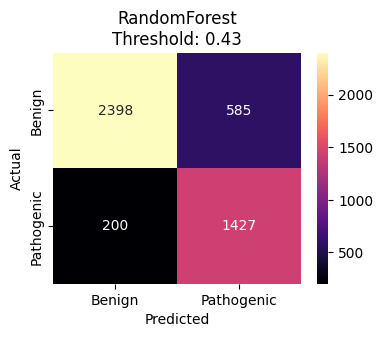

🧬 Evaluating: GradientBoost
Optimal Threshold: 0.44
Accuracy: 0.8293  |  F1-Score: 0.7807  |  ROC-AUC: 0.9072

              precision    recall  f1-score   support

           0       0.91      0.81      0.86      2983
           1       0.71      0.86      0.78      1627

    accuracy                           0.83      4610
   macro avg       0.81      0.84      0.82      4610
weighted avg       0.84      0.83      0.83      4610



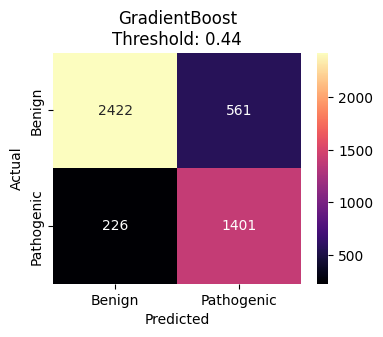

🧬 Evaluating: LogisticRegression
Optimal Threshold: 0.50
Accuracy: 0.7662  |  F1-Score: 0.7298  |  ROC-AUC: 0.8548

              precision    recall  f1-score   support

           0       0.92      0.70      0.79      2983
           1       0.62      0.89      0.73      1627

    accuracy                           0.77      4610
   macro avg       0.77      0.80      0.76      4610
weighted avg       0.82      0.77      0.77      4610



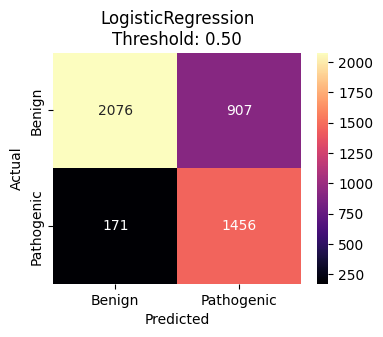

🧬 Evaluating: SVM
Optimal Threshold: 0.68
Accuracy: 0.7939  |  F1-Score: 0.7031  |  ROC-AUC: 0.8386

              precision    recall  f1-score   support

           0       0.83      0.85      0.84      2983
           1       0.72      0.69      0.70      1627

    accuracy                           0.79      4610
   macro avg       0.77      0.77      0.77      4610
weighted avg       0.79      0.79      0.79      4610



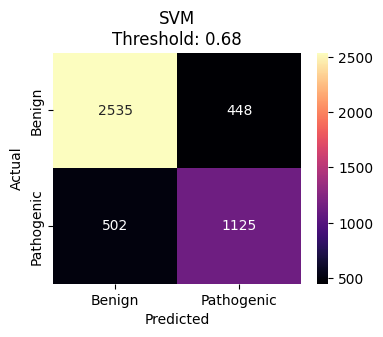

🧬 Evaluating: XGBoost
Optimal Threshold: 0.71
Accuracy: 0.8347  |  F1-Score: 0.7854  |  ROC-AUC: 0.9099

              precision    recall  f1-score   support

           0       0.91      0.82      0.87      2983
           1       0.72      0.86      0.79      1627

    accuracy                           0.83      4610
   macro avg       0.82      0.84      0.83      4610
weighted avg       0.85      0.83      0.84      4610



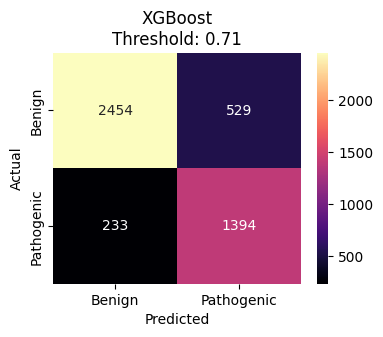

🧬 Evaluating: StackingEnsemble
Optimal Threshold: 0.36
Accuracy: 0.8304  |  F1-Score: 0.7840  |  ROC-AUC: 0.9110

              precision    recall  f1-score   support

           0       0.92      0.81      0.86      2983
           1       0.71      0.87      0.78      1627

    accuracy                           0.83      4610
   macro avg       0.82      0.84      0.82      4610
weighted avg       0.85      0.83      0.83      4610



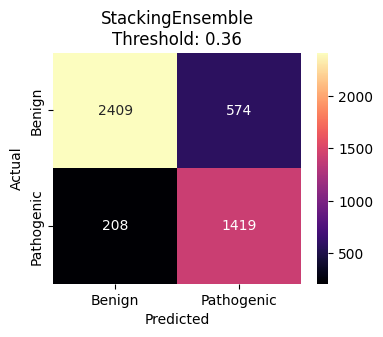


🏆 FINAL TUNED MODEL LEADERBOARD 🏆


,Model,Threshold,Accuracy,F1-Score,ROC-AUC
0,XGBoost,0.710000,0.834700,0.785400,0.909900
1,RandomForest,0.440000,0.829700,0.784300,0.908300
2,StackingEnsemble,0.360000,0.830400,0.784000,0.911000
3,GradientBoost,0.440000,0.829300,0.780700,0.907200
4,LogisticRegression,0.500000,0.766200,0.729800,0.854800
5,SVM,0.680000,0.793900,0.703100,0.838600


In [9]:
summary_data = []

for name, model in tuned_models.items():
    print("=" * 60)
    print(f"🧬 Evaluating: {name}")
    print("=" * 60)

    # 1. Get raw probabilities on the REAL, untouched test set
    probs = model.predict_proba(X_test_scaled)[:, 1]

    # 2. Find the optimal threshold mathematically
    precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    opt_idx = np.argmax(f1_scores)
    opt_thresh = thresholds[opt_idx]
    
    # 3. Predict using the optimal threshold
    preds = (probs >= opt_thresh).astype(int)

    # 4. Calculate metrics
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    
    summary_data.append({
        "Model": name, 
        "Threshold": round(opt_thresh, 2), 
        "Accuracy": round(acc, 4), 
        "F1-Score": round(f1, 4), 
        "ROC-AUC": round(auc, 4)
    })

    print(f"Optimal Threshold: {opt_thresh:.2f}")
    print(f"Accuracy: {acc:.4f}  |  F1-Score: {f1:.4f}  |  ROC-AUC: {auc:.4f}\n")
    print(classification_report(y_test, preds))

    # 5. Confusion Matrix 
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="magma", xticklabels=['Benign', 'Pathogenic'], yticklabels=['Benign', 'Pathogenic'])
    plt.title(f"{name}\nThreshold: {opt_thresh:.2f}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Display Final Leaderboard
print("\n🏆 FINAL TUNED MODEL LEADERBOARD 🏆")
summary_df = pd.DataFrame(summary_data).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
display(summary_df.style.background_gradient(cmap='Greens'))

🚀 INITIATING THE 'BIG 3' CALIBRATED ENSEMBLE 🚀

1. Initializing Advanced Boosters...
2. Wrapping models in Isotonic Calibrators...
3. Building Soft Voting Ensemble...

⏳ Training Calibrated XGBoost...
✅ Calibrated XGBoost | Threshold: 0.52 | Acc: 0.8341 | F1: 0.7863 | AUC: 0.9121

⏳ Training Calibrated LightGBM...
✅ Calibrated LightGBM | Threshold: 0.50 | Acc: 0.8317 | F1: 0.7824 | AUC: 0.9111

⏳ Training Calibrated CatBoost...
✅ Calibrated CatBoost | Threshold: 0.47 | Acc: 0.8334 | F1: 0.7874 | AUC: 0.9129

⏳ Training Soft Voting Ensemble...
✅ Soft Voting Ensemble | Threshold: 0.45 | Acc: 0.8325 | F1: 0.7864 | AUC: 0.9122

--- ULTIMATE ENSEMBLE REPORT ---
              precision    recall  f1-score   support

           0       0.92      0.81      0.86      2983
           1       0.72      0.87      0.79      1627

    accuracy                           0.83      4610
   macro avg       0.82      0.84      0.82      4610
weighted avg       0.85      0.83      0.84      4610



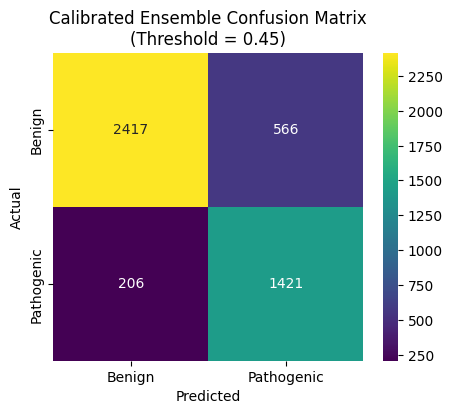


🏆 ADVANCED CALIBRATED LEADERBOARD 🏆


,Model,Threshold,Accuracy,F1-Score,ROC-AUC
0,Calibrated CatBoost,0.470000,0.833400,0.787400,0.912900
1,Soft Voting Ensemble,0.450000,0.832500,0.786400,0.912200
2,Calibrated XGBoost,0.520000,0.834100,0.786300,0.912100
3,Calibrated LightGBM,0.500000,0.831700,0.782400,0.911100


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    classification_report, precision_recall_curve, confusion_matrix
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier

# Import the "Big 3" Gradient Boosters
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print("🚀 INITIATING THE 'BIG 3' CALIBRATED ENSEMBLE 🚀\n")

# ==========================================
# 1. Initialize the Base Models
# ==========================================
print("1. Initializing Advanced Boosters...")

# XGBoost (Highly Regularized)
xgb_base = XGBClassifier(
    n_estimators=1000, max_depth=8, learning_rate=0.02, 
    gamma=2.0, min_child_weight=4, subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=42, n_jobs=-1
)

# LightGBM (Leaf-wise growth for asymmetrical biological patterns)
lgbm_base = LGBMClassifier(
    n_estimators=1000, learning_rate=0.02, num_leaves=64, 
    max_depth=-1, min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)

# CatBoost (Symmetric trees, highly robust to SMOTE noise)
cat_base = CatBoostClassifier(
    iterations=1000, learning_rate=0.02, depth=8,
    l2_leaf_reg=5, eval_metric='Logloss', random_seed=42, 
    verbose=0, thread_count=-1
)

# ==========================================
# 2. Probability Calibration
# ==========================================
print("2. Wrapping models in Isotonic Calibrators...")
# This ensures predict_proba() outputs true mathematical probabilities, 
# making our Threshold Auto-Tuner vastly more accurate.
xgb_calibrated = CalibratedClassifierCV(xgb_base, method='isotonic', cv=3)
lgbm_calibrated = CalibratedClassifierCV(lgbm_base, method='isotonic', cv=3)
cat_calibrated = CalibratedClassifierCV(cat_base, method='isotonic', cv=3)

# ==========================================
# 3. Soft Voting Ensemble
# ==========================================
print("3. Building Soft Voting Ensemble...")
voting_ensemble = VotingClassifier(
    estimators=[
        ('xgb', xgb_calibrated),
        ('lgbm', lgbm_calibrated),
        ('cat', cat_calibrated)
    ],
    voting='soft',
    weights=[1, 1, 1.5] # Giving CatBoost slightly more weight as it resists overfitting best
)

models = {
    "Calibrated XGBoost": xgb_calibrated,
    "Calibrated LightGBM": lgbm_calibrated,
    "Calibrated CatBoost": cat_calibrated,
    "Soft Voting Ensemble": voting_ensemble
}

# ==========================================
# 4. Train and Evaluate
# ==========================================
summary_data = []

# Note: X_train_clean and y_train_clean are from your SMOTE-Tomek cell
for name, model in models.items():
    print(f"\n⏳ Training {name}...")
    model.fit(X_train_clean, y_train_clean)
    
    # Predict on the un-SMOTEd test set
    probs = model.predict_proba(X_test_scaled)[:, 1]
    
    # Auto-Tuner
    precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    opt_idx = np.argmax(f1_scores)
    opt_thresh = thresholds[opt_idx]
    
    preds = (probs >= opt_thresh).astype(int)
    
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    
    summary_data.append({
        "Model": name, "Threshold": round(opt_thresh, 2), 
        "Accuracy": round(acc, 4), "F1-Score": round(f1, 4), "ROC-AUC": round(auc, 4)
    })
    
    print(f"✅ {name} | Threshold: {opt_thresh:.2f} | Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

    if name == "Soft Voting Ensemble":
        print("\n--- ULTIMATE ENSEMBLE REPORT ---")
        print(classification_report(y_test, preds))
        
        cm = confusion_matrix(y_test, preds)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Benign', 'Pathogenic'], yticklabels=['Benign', 'Pathogenic'])
        plt.title(f"Calibrated Ensemble Confusion Matrix\n(Threshold = {opt_thresh:.2f})")
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()

# ==========================================
# 5. Final Leaderboard
# ==========================================
print("\n🏆 ADVANCED CALIBRATED LEADERBOARD 🏆")
summary_df = pd.DataFrame(summary_data).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
display(summary_df.style.background_gradient(cmap='Greens'))